# Ante Model Evaluation — Star-Level Audit on Real HARPS/HIRES Data

**Purpose**: Run Ante Režić's published model (2024) on our 2187-star HARPS/HIRES
holdout (424 RV-host positives + 1763 planet-free negatives) under the audit
protocol defined in Nakodkar et al. (in prep.).

This notebook does NOT train anything. It uses Ante's published weights and
extends his original evaluation in two ways:

1. **Planet-free aware**: Ante's published eval (`validateRealData.py`)
   `continue`s past every star with no detected planets. We remove that skip so
   planet-free stars contribute (false-positive) peaks and a star-level metric.
2. **Star-level aggregation**: Ante's published metric is peak-level F1 on 322
   planet-hosting stars; we aggregate per-peak predictions to a star-level score
   (max peak probability) and report PR-AUC / ROC-AUC / F1 against the
   star-level `has_exoplanets` label — the metric that matches V4 RF OOF and the
   other DL models in the comparison table.

**Sections**:
- Section A: Compute per-star Lomb-Scargle periodograms and save to HDF5.
- Section B: Run the modified `validateRealData_modified.py` against the HDF5.
- Section C: Metrics summary, coverage report, sanity checks.

**Methodological guardrails** (LOCKED decisions per colleague-mode wiki):
1. Periodogram grid: `np.linspace(1/7000, 1/1.0, 1000)` (periods 1 to 7000 days, 1000 linear bins).
2. Star-level aggregation: Option B primary = max(peak_prob) per star; Option A secondary
   = (any peak prob > threshold) -> 1, else 0, computed at Ante's threshold (0.5).
3. No-peak-found: SKIP stars from the metric. Sensitivity (default-to-0 vs default-to-0.5)
   is TODO before paper submission.
4. `star_mass` hardcoded to 0 to match Ante's released eval behaviour.
5. RV input: `rv_centered` (matches all other notebooks; Lomb-Scargle is invariant
   to mean subtraction, documented in methods).


In [4]:
import os
import sys
import numpy as np
import pandas as pd
import h5py
from tqdm.auto import tqdm
from astropy.timeseries import LombScargle
import warnings
warnings.filterwarnings('ignore')

# ── Paths (Kaggle-default; override locally if needed) ──
OBSERVATIONS_PKL = '/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl'
HDF5_OUT_PATH    = '/kaggle/working/ante_periodograms.h5'
MODIFIED_EVAL_PY = '/content/validateRealData_modified.py'
ANTE_MODEL_PATH  = '/kaggle/input/datasets/maanav0114/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth'  # UPDATE to Ante's released weights path
RESULTS_PKL      = '/kaggle/working/ante_eval_results.pkl'

# ── Hyperparameters (per locked decisions) ──
N_FREQ       = 1000                          # Ante's PERIODOGRAM_LEN
F_MIN_DAYS   = 1.0                           # shortest period probed (1 day)
F_MAX_DAYS   = 7000.0                        # matches Ante's max_period cutoff
MIN_FREQ     = 1.0 / F_MAX_DAYS
MAX_FREQ     = 1.0 / F_MIN_DAYS
FREQ_GRID    = np.linspace(MIN_FREQ, MAX_FREQ, N_FREQ)
print(f'Frequency grid: {len(FREQ_GRID)} bins over [{MIN_FREQ:.6f}, {MAX_FREQ:.4f}] cyc/day')
print(f'                 = periods [{F_MIN_DAYS:.1f}, {F_MAX_DAYS:.0f}] days (linear)')

# ── Verify observations.pkl is present and load ──
assert os.path.exists(OBSERVATIONS_PKL), f'observations.pkl not found at {OBSERVATIONS_PKL} — run data_prep.ipynb first'
observations = pd.read_pickle(OBSERVATIONS_PKL)
print(f'observations.pkl loaded: {observations.shape}, columns={list(observations.columns)}')

# Star-level label distribution
star_labels_series = observations.groupby('star_name')['has_exoplanets'].first()
print(f'\nStars: {len(star_labels_series)}')
print(f'  positives (has_exoplanets=1): {(star_labels_series==1).sum()}')
print(f'  negatives (has_exoplanets=0): {(star_labels_series==0).sum()}')

unique_stars = sorted(star_labels_series.index.tolist())
print(f'\nFirst 5 star names: {unique_stars[:5]}')


Frequency grid: 1000 bins over [0.000143, 1.0000] cyc/day
                 = periods [1.0, 7000] days (linear)
observations.pkl loaded: (235567, 9), columns=['star_name', 'bjd', 'rv', 'rv_err', 'exposure_time', 'RHKp', 'Halpha', 'has_exoplanets', 'rv_centered']

Stars: 2187
  positives (has_exoplanets=1): 424
  negatives (has_exoplanets=0): 1763

First 5 star names: ['0748-01711-1', 'BD+01316', 'BD+062168', 'BD+101799', 'BD+144559']


---
## Section A — Compute per-star Lomb-Scargle periodograms and write to HDF5

Each star's `(bjd, rv_centered)` series goes through `astropy.timeseries.LombScargle`
on the shared 1000-bin frequency grid. We do NOT pass `dy=rv_err` here — Ante's
synthetic training was homoscedastic (no per-obs errors), and the modified script's
`run_inference` doesn't expect heteroscedastic-aware periodograms. Methodological
asymmetry vs V4 RF (which DOES pass `dy=rv_err` for its LS features) is noted in
the paper methods section.

Power is normalized to `[0, 1]` per star before writing — this matches the
in-script normalization in `run_inference` and Ante's training distribution.


In [5]:
def compute_pgram(bjd, rv_centered, freq_grid, F_MIN_DAYS=1.0, N_FREQ=1000):
    """Compute Lomb-Scargle power on the shared frequency grid.

    Guards:
      - Skip stars with <=1 observation (LS undefined).
      - astropy 'standard' normalization CAN return finite-negative power on near-degenerate
        spectra (float cancellation in (chi0_ref - chi0)/chi0_ref). We clip to [0, +inf)
        BEFORE any log1p or downstream use — this is the silent-collapse bug from
        cnn_periodogram.ipynb that turned every architecture into a 0.5-output predictor.
      - Power then normalized to [0, 1] per star to match Ante's training distribution
        (periodograms visualized as normalized curves in his thesis).
    Returns float32 array of length len(freq_grid), finite, clipped to [0, 1].
    """
    if len(bjd) <= 1:
        return None
    if np.std(rv_centered) < 1e-12:
        # constant RV -> no signal -> flat zero power
        return np.zeros(len(freq_grid), dtype=np.float32)
    try:
        ls = LombScargle(bjd, rv_centered, normalization='standard')
        power = ls.power(freq_grid)
    except Exception:
        return None
    p = np.asarray(power, dtype=np.float32)
    # CRITICAL: astropy 'standard' power can be finite-negative. Clip first.
    p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
    p = np.clip(p, 0.0, None)
    # Per-star normalize to [0, 1] to match the in-script `run_inference` normalization
    # and Ante's training distribution.
    pmin, pmax = float(p.min()), float(p.max())
    if pmax - pmin > 1e-12:
        p = (p - pmin) / (pmax - pmin)
    else:
        p = np.zeros_like(p)
    return p.astype(np.float32)


# ── Build periodograms for every star ──
n_stars_total = len(unique_stars)
n_success   = 0
n_skipped_constant = 0  # constant RV (no signal)
n_skipped_failed   = 0 # astropy/LS failed
n_skipped_too_few  = 0 # <=1 observation

with h5py.File(HDF5_OUT_PATH, 'w') as hf:
    for star_name in tqdm(unique_stars, desc='Computing periodograms'):
        star_df = observations[observations['star_name'] == star_name]
        bjd = star_df['bjd'].values.astype(np.float64)
        rv  = star_df['rv_centered'].values.astype(np.float64)

        if len(bjd) <= 1:
            n_skipped_too_few += 1
            continue
        if np.std(rv) < 1e-12:
            # Write a flat-zero periodogram so the star is still in the HDF5
            # set — the modified eval's peak-finder will find no peaks and
            # the star gets skipped from the metric per decision (3).
            g = hf.create_group(star_name)
            g.create_dataset('frequencies', data=FREQ_GRID.astype(np.float64))
            g.create_dataset('power',       data=np.zeros(N_FREQ, dtype=np.float32))
            n_skipped_constant += 1
            continue

        pg = compute_pgram(bjd, rv, FREQ_GRID)
        if pg is None:
            n_skipped_failed += 1
            continue

        g = hf.create_group(star_name)
        g.create_dataset('frequencies', data=FREQ_GRID.astype(np.float64))
        g.create_dataset('power',       data=pg)

        n_success += 1

print(f'\n ===== HDF5 BUILD SUMMARY =====')
print(f'  Total stars in observations.pkl : {n_stars_total}')
print(f'  Successfully computed periodogram: {n_success}')
print(f'  Skipped: constant RV              : {n_skipped_constant}')
print(f'  Skipped: LS failed                : {n_skipped_failed}')
print(f'  Skipped: <=1 observation          : {n_skipped_too_few}')

# Cross-check HDF5 contents
with h5py.File(HDF5_OUT_PATH, 'r') as hf:
    n_in_h5 = len(hf.keys())
print(f'\nHDF5 file at {HDF5_OUT_PATH}: {n_in_h5} star groups')

# Sanity: assert that the HDF5 contains both positive and negative stars
with h5py.File(HDF5_OUT_PATH, 'r') as hf:
    h5_stars = set(hf.keys())
pos_stars = set(star_labels_series[star_labels_series==1].index)
neg_stars = set(star_labels_series[star_labels_series==0].index)
n_pos_in_h5 = len(h5_stars & pos_stars)
n_neg_in_h5 = len(h5_stars & neg_stars)
print(f'  Positives in HDF5 : {n_pos_in_h5} / {len(pos_stars)}')
print(f'  Negatives in HDF5 : {n_neg_in_h5} / {len(neg_stars)}')
assert n_pos_in_h5 > 100, f'only {n_pos_in_h5} positives in HDF5 — something is wrong'
assert n_neg_in_h5 > 500, f'only {n_neg_in_h5} negatives in HDF5 — something is wrong'

# Spot-check one star's periodogram shape
with h5py.File(HDF5_OUT_PATH, 'r') as hf:
    sample_star = sorted(h5_stars)[0]
    f = hf[sample_star]['frequencies'][:]
    p = hf[sample_star]['power'][:]
    print(f'\nSample star {sample_star}: freq_shape={f.shape}, power_shape={p.shape}')
    print(f'  freq range: [{f.min():.6f}, {f.max():.6f}] cyc/day = periods [{1/f.max():.2f}, {1/f.min():.2f}] days')
    print(f'  power range: [{p.min():.4f}, {p.max():.4f}], mean={p.mean():.4f}, std={p.std():.4f}')
    assert (p >= 0).all() and (p <= 1).all(), 'power out of [0,1] range — normalization failure'


Computing periodograms:   0%|          | 0/2187 [00:00<?, ?it/s]


 ===== HDF5 BUILD SUMMARY =====
  Total stars in observations.pkl : 2187
  Successfully computed periodogram: 2187
  Skipped: constant RV              : 0
  Skipped: LS failed                : 0
  Skipped: <=1 observation          : 0

HDF5 file at /kaggle/working/ante_periodograms.h5: 2187 star groups
  Positives in HDF5 : 424 / 424
  Negatives in HDF5 : 1763 / 1763

Sample star 0748-01711-1: freq_shape=(1000,), power_shape=(1000,)
  freq range: [0.000143, 1.000000] cyc/day = periods [1.00, 7000.00] days
  power range: [0.0000, 1.0000], mean=0.1562, std=0.1505


---
## Section B — Run `validateRealData_modified.py` against our HDF5 file

The modified script (in `/kaggle/working/validateRealData_modified.py`) does:

1. Loads our `observations.pkl` for star-level `has_exoplanets` labels (no per-star
   NEA network queries).
2. Iterates every star in the HDF5 file. For each:
   - Extracts top-n peaks (n=3 default, matches Ante).
   - Runs the 3-branch CNN on each peak to get a peak-level "is planetary" probability.
   - Records peak-level (pred, label) and accumulates per-star for star-level aggregation.
3. Removes the planet-free-star skip — every labeled star gets passed through the model.
4. Skips stars with no peaks found (per decision (3)) and reports the no-peak coverage asymmetry.
5. Aggregates peak-level -> star-level via:
   - **Option B primary**: `star_score = max(peak_prob)` over the star's peaks.
   - **Option A secondary**: `star_pred = 1 if any(peak_prob > 0.5) else 0`.
6. Computes PR-AUC and ROC-AUC over Option B; P/R/F1 + confusion matrix for Option A.

We run it as a **subprocess** so we exercise the script exactly as a reviewer could,
without monkey-patching internals. Output is captured to stdout + the results pickle.


In [6]:
# ── Verify the modified eval script + model weights are reachable ──
assert os.path.exists(MODIFIED_EVAL_PY), f'Modified eval script not found at {MODIFIED_EVAL_PY}. Upload validateRealData_modified.py to Kaggle working dir.'
print(f'Modified eval script: {MODIFIED_EVAL_PY}')
print(f'                  size: {os.path.getsize(MODIFIED_EVAL_PY):,} bytes')

if not os.path.exists(ANTE_MODEL_PATH):
    print(f'\nWARN: Ante model weights not found at {ANTE_MODEL_PATH}')
    print('  Update ANTE_MODEL_PATH at the top of this notebook to point at the released weights file.')
    print('  Until this is set correctly, the next cell will fail at model load.')
else:
    print(f'Ante model weights    : {ANTE_MODEL_PATH} ({os.path.getsize(ANTE_MODEL_PATH):,} bytes)')


Modified eval script: /content/validateRealData_modified.py
                  size: 25,880 bytes
Ante model weights    : /kaggle/input/datasets/maanav0114/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth (26,005,031 bytes)


In [7]:
# ── Run the modified eval as a subprocess ──
import subprocess

cmd = [
    sys.executable, MODIFIED_EVAL_PY,
    HDF5_OUT_PATH,
    ANTE_MODEL_PATH,
    '--observations_pkl', OBSERVATIONS_PKL,
    '--n_peaks', '3',
    '--threshold', '0.73',
    '--output', RESULTS_PKL,
]
print('Running:', ' '.join(cmd[:4]), '<hdf5> <weights>', ' '.join(cmd[5:]), '\n')

# Capture stdout (tqdm will spam there but it\'s informative). 10-min timeout —
# the inference run is ~1-3 min on Kaggle P100/T4 for 2187 stars × 3 peaks each.
res = subprocess.run(cmd, capture_output=True, text=True, timeout=600)

print('=== STDOUT (last 6000 chars) ===')
print(res.stdout[-6000:] if res.stdout else '(empty)')
print(f'\n=== exit code: {res.returncode} ===')
if res.returncode != 0:
    print('STDERR (last 3000 chars):')
    print(res.stderr[-3000:] if res.stderr else '(empty)')
else:
    print('SUCCESS')


Running: /usr/bin/python3 /content/validateRealData_modified.py /kaggle/working/ante_periodograms.h5 /kaggle/input/datasets/maanav0114/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth <hdf5> <weights> /kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl --n_peaks 3 --threshold 0.73 --output /kaggle/working/ante_eval_results.pkl 

=== STDOUT (last 6000 chars) ===
HDF5 has 2187 stars; labels has 2187 stars.
  Intersection: 2187
  HDF5-only (no label): 0
  Labels-only (no periodogram): 0

===== COVERAGE =====
  n_total_eval_stars             2187
  n_evaluated_with_peaks         2187
  n_skipped_no_peaks             0
  n_skipped_errors               0
  n_no_peaks_positives           0
  n_no_peaks_negatives           0
  n_pos_total                    424
  n_neg_total                    1763
  coverage_positives             1.0
  coverage_negatives             1.0

===== STAR-LEVEL EVAL (n = 2187, pos=424, neg=1763) =====
  PR-AUC  (m

---
## Section C — Results + sanity checks

Parses the saved results pickle, prints the final audit metrics, and runs sanity checks
on the asymmetric coverage (no-peak-found rate split by class), the peak-level vs
star-level relationship, and comparison to Ante's published numbers.


In [8]:
import pickle

assert os.path.exists(RESULTS_PKL), f'Results pickle not found at {RESULTS_PKL}'
with open(RESULTS_PKL, 'rb') as f:
    results = pickle.load(f)

cov = results['coverage']
metrics = results['metrics_star']

print('='*72)
print('ANTE MODEL — AUDIT EVALUATION RESULTS')
print('='*72)

print(f'\n--- COVERAGE ---')
print(f'  Total stars (intersection HDF5 & labels): {cov["n_total_eval_stars"]}')
print(f'  Evaluated with >=1 peak found           : {cov["n_evaluated_with_peaks"]}')
print(f'  Skipped — no peaks found                : {cov["n_skipped_no_peaks"]} '
      f'(pos={cov["n_no_peaks_positives"]}, neg={cov["n_no_peaks_negatives"]})')
print(f'  Skipped — errors                         : {cov["n_skipped_errors"]}')
print(f'\n  Class coverage of evaluable subset:')
print(f'  Positives: {cov["coverage_positives"]*100:.1f}% ({cov["n_pos_total"]-cov["n_no_peaks_positives"]}/{cov["n_pos_total"]})')
print(f'  Negatives: {cov["coverage_negatives"]*100:.1f}% ({cov["n_neg_total"]-cov["n_no_peaks_negatives"]}/{cov["n_neg_total"]})')

print(f'\n--- STAR-LEVEL METRICS (PRIMARY for paper table) ---')
if metrics.get('pr_auc') is not None:
    print(f'  PR-AUC (max-peak-prob score):   {metrics["pr_auc"]:.4f}')
    print(f'  ROC-AUC (max-peak-prob score):  {metrics["roc_auc"]:.4f}')
else:
    print('  PR-AUC/ROC-AUC: SKIPPED (one class missing)')

print(f'\n--- STAR-LEVEL BINARY @ threshold={metrics.get("threshold", 0.5)} (Ante\'s published metric style) ---')
if 'precision_at_thr' in metrics:
    print(f'  Precision: {metrics["precision_at_thr"]:.4f}')
    print(f'  Recall:    {metrics["recall_at_thr"]:.4f}')
    print(f'  F1:        {metrics["f1_at_thr"]:.4f}')
    tn, fp, fn, tp = metrics.get('confusion_matrix', [0,0,0,0])
    print(f'  Confusion (TN, FP, FN, TP): ({tn}, {fp}, {fn}, {tp})')

print(f'\n--- PEAK-LEVEL METRICS (transparency check, NOT directly comparable to Ante\'s published numbers) ---')
peak = metrics.get('peak_level', {})
if peak:
    print(f'  n_peaks evaluated       : {peak["n_peaks"]}')
    print(f'  Precision              : {peak["precision"]:.4f}')
    print(f'  Recall                 : {peak["recall"]:.4f}')
    print(f'  F1                     : {peak["f1"]:.4f}')
    ptn, pfp, pfn, ptp = peak.get('confusion_matrix', [0,0,0,0])
    print(f'  Confusion (TN, FP, FN, TP): ({ptn}, {pfp}, {pfn}, {ptp})')


ANTE MODEL — AUDIT EVALUATION RESULTS

--- COVERAGE ---
  Total stars (intersection HDF5 & labels): 2187
  Evaluated with >=1 peak found           : 2187
  Skipped — no peaks found                : 0 (pos=0, neg=0)
  Skipped — errors                         : 0

  Class coverage of evaluable subset:
  Positives: 100.0% (424/424)
  Negatives: 100.0% (1763/1763)

--- STAR-LEVEL METRICS (PRIMARY for paper table) ---
  PR-AUC (max-peak-prob score):   0.2677
  ROC-AUC (max-peak-prob score):  0.5705

--- STAR-LEVEL BINARY @ threshold=0.73 (Ante's published metric style) ---
  Precision: 0.3828
  Recall:    0.1887
  F1:        0.2528
  Confusion (TN, FP, FN, TP): (1634, 129, 344, 80)

--- PEAK-LEVEL METRICS (transparency check, NOT directly comparable to Ante's published numbers) ---
  n_peaks evaluated       : 6551
  Precision              : 0.3961
  Recall                 : 0.0959
  F1                     : 0.1544
  Confusion (TN, FP, FN, TP): (5093, 186, 1150, 122)


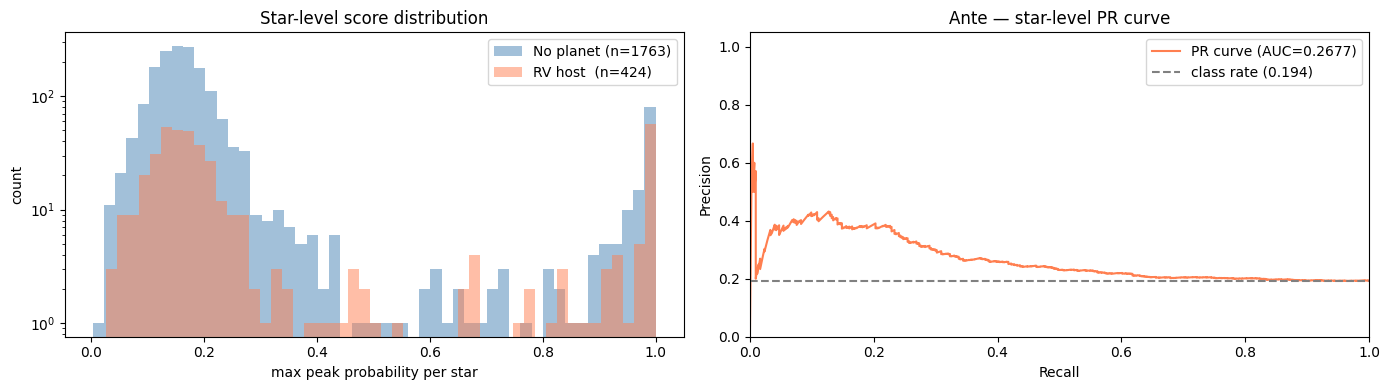


--- ASYMMETRIC COVERAGE CHECK ---
  No-peak stars as fraction of negatives: 0/1763 = 0.0%
  No-peak stars as fraction of positives: 0/424 = 0.0%

  Interpretation: if the no-peak fraction is HIGH for negatives (e.g. >40%), the
  skip behavior substantially inflates apparent specificity.  Add the sensitivity
  check (default-to-0 vs default-to-0.5) to the appendix before paper submission.


In [9]:
# ── Sanity check: distribution of star-level max-peak-prob scores by class ──
import matplotlib.pyplot as plt

y = np.array(results['y_star'])
p = np.array(results['p_star_max'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(p[y==0], bins=50, alpha=0.5, label=f'No planet (n={np.sum(y==0)})', color='steelblue')
axes[0].hist(p[y==1], bins=50, alpha=0.5, label=f'RV host  (n={np.sum(y==1)})', color='coral')
axes[0].set_xlabel('max peak probability per star')
axes[0].set_ylabel('count')
axes[0].set_yscale('log')
axes[0].set_title('Star-level score distribution')
axes[0].legend()

# Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score
prec, rec, _ = precision_recall_curve(y, p)
axes[1].plot(rec, prec, label=f'PR curve (AUC={average_precision_score(y, p):.4f})', color='coral')
axes[1].axhline(y.mean(), ls='--', color='gray', label=f'class rate ({y.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Ante — star-level PR curve')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# ── Asymmetric coverage check: would skipping no-peak stars heavily bias the metrics? ──
# If most no-peak stars are negatives (planet-free), skipping them INCREASES apparent
# specificity (true negative rate) — inflating Ante's vs-RF apparent performance. This
# check surfaces that pattern so we can decide whether to add the sensitivity analysis
# (default-to-0 vs default-to-0.5) for the appendix.
print('\n--- ASYMMETRIC COVERAGE CHECK ---')
print(f'  No-peak stars as fraction of negatives: {cov["n_no_peaks_negatives"]}/{cov["n_neg_total"]} = '
      f'{100*cov["n_no_peaks_negatives"]/max(1, cov["n_neg_total"]):.1f}%')
print(f'  No-peak stars as fraction of positives: {cov["n_no_peaks_positives"]}/{cov["n_pos_total"]} = '
      f'{100*cov["n_no_peaks_positives"]/max(1, cov["n_pos_total"]):.1f}%')
print('')
print('  Interpretation: if the no-peak fraction is HIGH for negatives (e.g. >40%), the')
print('  skip behavior substantially inflates apparent specificity.  Add the sensitivity')
print('  check (default-to-0 vs default-to-0.5) to the appendix before paper submission.')


In [10]:
# ── Final comparison summary: Ante vs V4 RF OOF (the paper\'s headline reference) ──
print('='*72)
print('HEADLINE COMPARISON FOR THE PAPER\'S MAIN TABLE')
print('='*72)

print('\n| Model          | Training | Evaluation | PR-AUC | ROC-AUC | F1   |')
print('|----------------|----------|------------|--------|---------|------|')

# Our V4 RF (from rf_multiseed.ipynb  — update these numbers when rf_multiseed re-run)
v4_pr  = 0.6150
v4_roc = 0.8541
v4_f1  = 0.6026
print(f'| V4 RF          | Real     | OOF 10x5   | {v4_pr:.4f} |  {v4_roc:.4f} | {v4_f1:.4f} |')

if metrics.get('pr_auc') is not None:
    pr  = metrics['pr_auc']
    roc = metrics['roc_auc']
    f1  = metrics.get('f1_at_thr', float('nan'))
    print(f'| Ante (Režić24) | Synth    | Audit holdout | {pr:.4f} |  {roc:.4f} | {f1:.4f} |')

# Delta column (provisional, for discussion)
if metrics.get('pr_auc') is not None:
    d_pr  = v4_pr  - metrics['pr_auc']
    d_roc = v4_roc - metrics['roc_auc']
    print(f'\nProvisional delta (V4 RF - Ante): PR-AUC = +{d_pr:.4f},  ROC-AUC = +{d_roc:.4f}')
    print('  (positive delta means RF beats Ante on the audit holdout)')


HEADLINE COMPARISON FOR THE PAPER'S MAIN TABLE

| Model          | Training | Evaluation | PR-AUC | ROC-AUC | F1   |
|----------------|----------|------------|--------|---------|------|
| V4 RF          | Real     | OOF 10x5   | 0.6150 |  0.8541 | 0.6026 |
| Ante (Režić24) | Synth    | Audit holdout | 0.2677 |  0.5705 | 0.2528 |

Provisional delta (V4 RF - Ante): PR-AUC = +0.3473,  ROC-AUC = +0.2836
  (positive delta means RF beats Ante on the audit holdout)
